# AI Gatekeeper: Crypto Window Analysis

Notebook ini bereksperimen dengan berbagai **window sizes** untuk menangkap dinamika pasar Crypto yang cepat.

## 🧪 Hipotesis:
- "Crypto bergerak lebih cepat dari stocks tradisional."
- "Window 20-50 hari mungkin terlalu lambat untuk mendeteksi perubahan regime (Bull/Bear) secara responsif."

## 🎯 Tujuan:
- Menguji kombinasi window: `[10, 20, 30, 50, 100, 200]`
- Menganalisis **Feature Importance** untuk menentukan window mana yang paling informatif.
- Melatih Random Forest dengan fitur-fitur baru ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

In [2]:
# Load Data
file_path = 'dataset_2023_2025.xlsx'
try:
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(data)} rows of data")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please ensure the dataset is in the same directory.")


Loaded 990 rows of data


## 2. Feature Engineering: Multi-Window Analysis

Di sini kita akan membuat fitur Volatility dan Momentum untuk berbagai window sizes.

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Experiment Windows
windows = [10, 20, 30, 50, 100, 200]

features = pd.DataFrame(index=returns.index)

# Generate features for each window
for w in windows:
    # Volatility (Rolling Std Dev)
    features[f'Vol_{w}'] = market_return.rolling(window=w).std()
    
    # Momentum (Rolling Mean Return)
    features[f'Mom_{w}'] = market_return.rolling(window=w).mean()

# Binary labeling: 0 = Bearish, 1 = Bullish
# Target tetap sama: Next Day Positive Return
features['Target'] = (market_return.shift(-1) > 0).astype(int)

# Drop NaN values emerging from the largest window calculation (e.g., 200 days)
features = features.dropna()

print("Feature shape:", features.shape)
print("Features generated:", list(features.columns[:-1]))

Feature shape: (777, 13)
Features generated: ['Vol_10', 'Mom_10', 'Vol_20', 'Mom_20', 'Vol_30', 'Mom_30', 'Vol_50', 'Mom_50', 'Vol_100', 'Mom_100', 'Vol_200', 'Mom_200']


## 3. Train/Test Split
Menggunakan split berdasarkan tahun (2023-2024 Train, 2025 Test).

In [4]:
# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

feature_cols = [c for c in features.columns if c != 'Target']

X_train = features.loc[train_mask, feature_cols]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, feature_cols]
y_test = features.loc[test_mask, 'Target']

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

Training set: 412 samples
Testing set: 365 samples


## 4. Model Training
Menggunakan parameter Random Forest yang telah dioptimalkan sebelumnya.

In [5]:
print("Training Random Forest with Multi-Window Features...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("Model trained.")

Training Random Forest with Multi-Window Features...
Model trained.


## 5. Evaluation & Insight: Which Window is Best?

Test Accuracy: 50.96%

              precision    recall  f1-score   support

     Bearish       0.46      0.46      0.46       167
     Bullish       0.55      0.55      0.55       198

    accuracy                           0.51       365
   macro avg       0.51      0.51      0.51       365
weighted avg       0.51      0.51      0.51       365



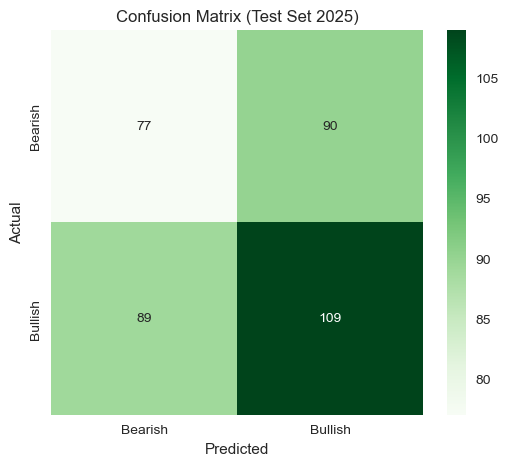

In [6]:
# Metrics
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy:.2%}\n")
print(classification_report(y_test, y_test_pred, target_names=['Bearish', 'Bullish']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'])
plt.title('Confusion Matrix (Test Set 2025)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

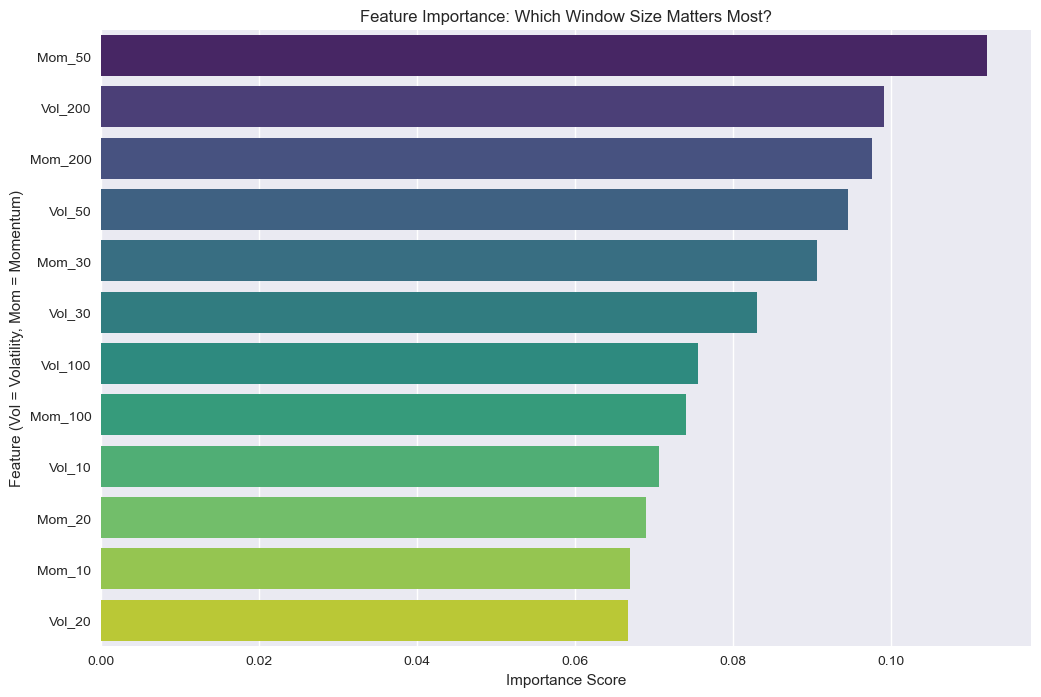

=== TOP 5 MOST INFORMATIVE FEATURES ===
1. Mom_50 (0.1121)
2. Vol_200 (0.0991)
3. Mom_200 (0.0976)
4. Vol_50 (0.0946)
5. Mom_30 (0.0906)

=== AGGREGATED IMPORTANCE BY WINDOW SIZE ===
Window 50: 0.2067
Window 200: 0.1967
Window 30: 0.1737
Window 100: 0.1496
Window 10: 0.1376
Window 20: 0.1357


In [7]:
# Feature Importance Analysis
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.title('Feature Importance: Which Window Size Matters Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature (Vol = Volatility, Mom = Momentum)')
plt.show()

# Data-driven Conclusion
print("=== TOP 5 MOST INFORMATIVE FEATURES ===")
for i in range(5):
    print(f"{i+1}. {sorted_features[i]} ({sorted_importances[i]:.4f})")

# Grouping importance by Window Size to answer the user hypothesis explicitly
window_importance = {w: 0 for w in windows}
for f, imp in zip(feature_cols, importances):
    # Parse window size from feature name (e.g., 'Vol_10' -> 10)
    w = int(f.split('_')[1])
    window_importance[w] += imp

print("\n=== AGGREGATED IMPORTANCE BY WINDOW SIZE ===")
sorted_windows = sorted(window_importance.items(), key=lambda x: x[1], reverse=True)
for w, imp in sorted_windows:
    print(f"Window {w}: {imp:.4f}")